# 📓 Notebook 6 — Final Fixes & Project Completion

## Honest reading of NB5 results

| Metric | NB5 value | What it means |
|--------|-----------|---------------|
| avg \|delta\| bull = 0.021 | ✅ | Delta target achieved — near-zero exposure |
| avg \|delta\| bear = 0.007 | ✅ | Also near-zero in bear — genuine hedging |
| Bull PnL = +0.0039 | ✅ | Small but positive |
| Bear PnL = −0.0001 | ✅ | Essentially zero — market neutral! |
| Sharpe bear = −27.558 | ❌ numerical | std≈0 makes formula explode — not real |
| Bull/Bear ratio = 40.81× | ❌ numerical | 0.0039/0.0001 — dividing near-zeros |
| Bear SellU = 88% | ❌ real problem | Agent goes short underlying in bear markets |
| p-value bull = 0.41 | ❌ | RL not yet significantly better than BS |
| Win rate bull = 47.3% | ❌ | Slightly below 50% |

## The two real remaining problems

**Problem 1 — SellU=88% in bear:** The agent discovered that selling the underlying
in a falling market makes money. It's swapping bull-momentum for bear-momentum.
Fix: penalize SellU overuse symmetrically with BuyU overuse.

**Problem 2 — p=0.41, win rate 47.3%:** RL PnL is only slightly above BS (+0.0039 vs
+0.0004). The RL advantage is real but the variance across episodes is too high for
statistical significance. Fix: more training (3M total steps) + increase episode variety.

**What is NOT a problem:** The Sharpe of −27.558 in bear and the 40.81× ratio are
both numerical artifacts from dividing near-zero PnL by near-zero std. The actual
bear PnL of −0.0001 is better than BS's −0.0008 — the agent IS more neutral.

## Fixes
- Symmetric overload penalty: SellU overuse penalized same as BuyU overuse
- Sharpe calculation made robust: use rolling window std with minimum floor
- 3M total steps with cosine LR schedule
- More evaluation episodes (200) for better statistical power
- Final complete project summary

In [1]:
import subprocess, sys
for p in ["gymnasium","stable-baselines3[extra]","numpy","pandas",
           "scipy","matplotlib","seaborn","tqdm","torch"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",p])

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from scipy.stats import norm as spn, ttest_ind, mannwhitneyu
from tqdm.notebook import tqdm

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT): ROOT = os.path.abspath(".")

PATHS = {
    "processed":   os.path.join(ROOT, "data", "processed"),
    "artifacts":   os.path.join(ROOT, "artifacts"),
    "models_nb6":  os.path.join(ROOT, "models", "nb6"),
    "results":     os.path.join(ROOT, "results"),
    "tb_logs":     os.path.join(ROOT, "tb_logs"),
    "checkpoints": os.path.join(ROOT, "checkpoints"),
    "nb6":         os.path.join(ROOT, "results", "nb6"),
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
df = pd.read_csv(os.path.join(PATHS["processed"], "all_assets_features.csv"),
                 parse_dates=["date"])
FEATURE_COLS = [c for c in [
    "log_return","pct_return_1d","pct_return_5d","pct_return_20d",
    "rvol_5d","rvol_10d","rvol_21d","rvol_63d",
    "delta_call","delta_put","gamma","vega","theta_call",
    "atm_call_price","atm_put_price",
    "price_to_sma20","bband_pct","rsi_14","volume_ratio","regime"
] if c in df.columns]
df = df.dropna(subset=FEATURE_COLS+["close","sigma"]).reset_index(drop=True)
train_df = df[df["split"]=="train"].reset_index(drop=True)
val_df   = df[df["split"]=="val"].reset_index(drop=True)

def compute_class_norms(train_df, feature_cols):
    return {cls: {
        "mean": train_df[train_df["asset_class"]==cls][feature_cols].mean().values.astype(np.float32),
        "std":  train_df[train_df["asset_class"]==cls][feature_cols].std().values.astype(np.float32)
    } for cls in train_df["asset_class"].unique()}

class_norms = compute_class_norms(train_df, FEATURE_COLS)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Features: {len(FEATURE_COLS)}")

Train: 11,339 | Val: 3,791 | Features: 20


---
## Section 1: FinalHedgingEnv — Symmetric Overload Penalty

In [3]:
class FinalHedgingEnv(gym.Env):
    """
    Final environment. One change from DeltaNeutralEnv (NB5):
    Overload penalty is now SYMMETRIC — applies to both BuyU AND SellU overuse.
    NB5 only penalized BuyU>40%, leaving SellU free to accumulate short positions.
    """
    TRANSACTION_COST_PCT  = 0.001
    RISK_FREE_RATE        = 0.045
    MAX_POSITION          = 5
    MAX_UNDERLYING_UNITS  = 20
    DELTA_LAMBDA          = 0.05
    EPISODE_LENGTH        = 63
    INITIAL_CASH          = 10_000.0
    VAR_LAMBDA            = 0.04
    CLOSE_ALL_PENALTY     = 0.002
    HEDGE_BONUS           = 0.002
    UNDERLYING_FRACTION   = 0.1
    OVERLOAD_THRESHOLD    = 0.35   # either BuyU or SellU > 35% → overload
    OVERLOAD_PENALTY_COEF = 0.005  # per % above threshold

    def __init__(self, data_df, feature_cols, mode="train",
                 episode_length=63, class_norms=None, seed=42):
        super().__init__()
        self.data          = data_df.copy().reset_index(drop=True)
        self.feature_cols  = feature_cols
        self.mode          = mode
        self.episode_length= episode_length
        self.rng           = np.random.default_rng(seed)
        self.class_norms   = class_norms or {}

        obs_dim = len(feature_cols) + 14  # 13 from NB5 + 1 SellU freq signal
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(10)
        self._build_episode_index()

    def _build_episode_index(self):
        self._episode_starts = []
        for sym in self.data["symbol"].unique():
            idx  = self.data[self.data["symbol"]==sym].index.tolist()
            step = max(1, self.episode_length // 3)
            for i in range(0, len(idx)-self.episode_length, step):
                self._episode_starts.append((sym, idx[i]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        ep_idx = self.rng.integers(0, len(self._episode_starts))
        self._sym, self._start = self._episode_starts[ep_idx]
        self._end   = min(self._start + self.episode_length, len(self.data)-1)
        self._step  = 0
        self._asset_class = self.data.iloc[self._start].get("asset_class", "equities")
        self._cash  = self.INITIAL_CASH
        self._long_calls = self._short_calls = 0
        self._long_puts  = self._short_puts  = 0
        self._underlying_pos  = 0.0
        self._long_calls_otm  = self._long_puts_otm = 0
        self._pnl_history     = []
        self._last_port_val   = self.INITIAL_CASH
        self._high_delta_steps= 0
        self._close_all_count = 0
        self._recent_actions  = []
        return self._get_obs(), {}

    def _current_row(self):
        return self.data.iloc[min(self._start+self._step, self._end)]

    def _get_prices(self, row):
        S   = float(row["close"])
        sig = max(float(row.get("sigma", 0.20)), 0.05)
        T   = 30/252
        cp  = float(row.get("atm_call_price", S*sig*np.sqrt(T)*0.4))
        pp  = float(row.get("atm_put_price",  S*sig*np.sqrt(T)*0.38))
        dc  = float(row.get("delta_call", 0.5))
        dp  = dc - 1.0
        d1c = (np.log(S/(S*1.1))+(self.RISK_FREE_RATE+0.5*sig**2)*T)/(sig*np.sqrt(T)+1e-9)
        d1p = (np.log(S/(S*0.9))+(self.RISK_FREE_RATE+0.5*sig**2)*T)/(sig*np.sqrt(T)+1e-9)
        otm_cp = max(S*spn.cdf(d1c)-S*1.1*np.exp(-self.RISK_FREE_RATE*T)*spn.cdf(d1c-sig*np.sqrt(T)),0.01)
        otm_pp = max(S*0.9*np.exp(-self.RISK_FREE_RATE*T)*spn.cdf(-(d1p-sig*np.sqrt(T)))-S*spn.cdf(-d1p),0.01)
        return S, cp, pp, dc, dp, otm_cp, otm_pp

    def _port_val(self, S, cp, pp, otm_cp, otm_pp):
        return (self._cash
                + self._long_calls*cp    - self._short_calls*cp
                + self._long_puts*pp     - self._short_puts*pp
                + self._long_calls_otm*otm_cp + self._long_puts_otm*otm_pp
                + self._underlying_pos*S*self.UNDERLYING_FRACTION)

    def _normalize(self, raw):
        if self._asset_class not in self.class_norms: return raw
        mu  = self.class_norms[self._asset_class]["mean"]
        std = self.class_norms[self._asset_class]["std"]
        return np.clip((raw-mu)/(std+1e-8), -5, 5)

    def _get_obs(self):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)
        raw = np.array([row[c] if not pd.isna(row[c]) else 0.0
                        for c in self.feature_cols], dtype=np.float32)
        mkt = self._normalize(raw)

        port_delta = (self._long_calls*dc - self._short_calls*dc
                      + self._long_puts*dp - self._short_puts*dp
                      + self._underlying_pos*self.UNDERLYING_FRACTION)
        pv         = self._port_val(S, cp, pp, otm_cp, otm_pp)
        unrealised = (pv - self.INITIAL_CASH) / self.INITIAL_CASH
        total_pos  = self._long_calls+self._short_calls+self._long_puts+self._short_puts
        hedge_gap  = (-port_delta/self.UNDERLYING_FRACTION) - self._underlying_pos

        recent = np.array(self._recent_actions[-20:]) if self._recent_actions else np.array([])
        recent_buyu = (recent==5).mean() if len(recent) else 0.0
        recent_sellu= (recent==6).mean() if len(recent) else 0.0  # NEW

        port_feat = np.array([
            self._long_calls   / self.MAX_POSITION,
            self._short_calls  / self.MAX_POSITION,
            self._long_puts    / self.MAX_POSITION,
            self._short_puts   / self.MAX_POSITION,
            self._underlying_pos / self.MAX_UNDERLYING_UNITS,
            self._cash / self.INITIAL_CASH - 1.0,
            np.clip(unrealised, -2, 2),
            np.clip(port_delta / 5.0, -3, 3),
            self._step / self.episode_length,
            total_pos / (self.MAX_POSITION*4),
            np.clip(hedge_gap / 10.0, -3, 3),
            self._close_all_count / max(self._step, 1),
            recent_buyu,
            recent_sellu,   # NEW: SellU overload awareness
        ], dtype=np.float32)

        return np.nan_to_num(np.concatenate([mkt, port_feat]),
                              nan=0.0, posinf=5.0, neginf=-5.0)

    def step(self, action: int):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)
        tc = self.TRANSACTION_COST_PCT; tc_cost = 0.0
        self._recent_actions.append(action)

        if action == 0: pass
        elif action == 1 and self._long_calls < self.MAX_POSITION:
            if self._cash >= cp*(1+tc):
                self._cash -= cp*(1+tc); self._long_calls += 1; tc_cost = cp*tc
        elif action == 2 and self._short_calls < self.MAX_POSITION:
            self._cash += cp*(1-tc); self._short_calls += 1; tc_cost = cp*tc
        elif action == 3 and self._long_puts < self.MAX_POSITION:
            if self._cash >= pp*(1+tc):
                self._cash -= pp*(1+tc); self._long_puts += 1; tc_cost = pp*tc
        elif action == 4 and self._short_puts < self.MAX_POSITION:
            self._cash += pp*(1-tc); self._short_puts += 1; tc_cost = pp*tc
        elif action == 5:
            if (self._underlying_pos < self.MAX_UNDERLYING_UNITS
                    and self._cash >= S*self.UNDERLYING_FRACTION*(1+tc)):
                self._cash -= S*self.UNDERLYING_FRACTION*(1+tc)
                self._underlying_pos += 1.0; tc_cost = S*self.UNDERLYING_FRACTION*tc
        elif action == 6 and self._underlying_pos >= 1.0:
            self._cash += S*self.UNDERLYING_FRACTION*(1-tc)
            self._underlying_pos -= 1.0; tc_cost = S*self.UNDERLYING_FRACTION*tc
        elif action == 7:
            opts = (self._long_calls+self._short_calls+
                    self._long_puts+self._short_puts)
            self._cash += self._long_calls*cp*(1-tc) - self._short_calls*cp*(1+tc)
            self._cash += self._long_puts*pp*(1-tc)  - self._short_puts*pp*(1+tc)
            self._cash += self._underlying_pos*S*self.UNDERLYING_FRACTION*(1-tc)
            tc_cost = opts*max(cp,pp)*tc*2 + self.CLOSE_ALL_PENALTY*self.INITIAL_CASH
            self._long_calls=self._short_calls=0
            self._long_puts=self._short_puts=0
            self._underlying_pos=0.0; self._close_all_count+=1
        elif action == 8 and self._long_calls_otm < self.MAX_POSITION:
            if self._cash >= otm_cp*(1+tc):
                self._cash -= otm_cp*(1+tc); self._long_calls_otm+=1; tc_cost=otm_cp*tc
        elif action == 9 and self._long_puts_otm < self.MAX_POSITION:
            if self._cash >= otm_pp*(1+tc):
                self._cash -= otm_pp*(1+tc); self._long_puts_otm+=1; tc_cost=otm_pp*tc

        self._step += 1
        done = (self._start + self._step) >= self._end

        nr = self._current_row()
        Sn,cpn,ppn,dcn,dpn,otm_cpn,otm_ppn = self._get_prices(nr)
        pv       = self._port_val(Sn,cpn,ppn,otm_cpn,otm_ppn)
        step_pnl = (pv - self._last_port_val) / self.INITIAL_CASH
        self._last_port_val = pv
        self._pnl_history.append(step_pnl)

        port_delta = (self._long_calls*dcn - self._short_calls*dcn
                      + self._long_puts*dpn - self._short_puts*dpn
                      + self._underlying_pos*self.UNDERLYING_FRACTION)
        total_pos  = self._long_calls+self._short_calls+self._long_puts+self._short_puts

        delta_penalty = self.DELTA_LAMBDA * (port_delta**2)
        tc_penalty    = tc_cost / self.INITIAL_CASH

        if abs(port_delta) > 0.5:
            self._high_delta_steps += 1
            escalation = 0.001 * self._high_delta_steps
        else:
            self._high_delta_steps = 0; escalation = 0.0

        cvar_pen = 0.0
        if len(self._pnl_history) >= 15:
            arr  = np.array(self._pnl_history)
            var5 = np.percentile(arr, 5)
            tail = arr[arr<=var5]
            cvar_pen = self.VAR_LAMBDA * max(-(tail.mean() if len(tail) else var5), 0)

        hedge_bonus = (self.HEDGE_BONUS
                       if total_pos >= 2 and abs(port_delta) < 0.25 else 0.0)

        recent = np.array(self._recent_actions[-20:])
        recent_buyu  = (recent==5).mean()
        recent_sellu = (recent==6).mean()
        # SYMMETRIC overload penalty: penalise BOTH directions
        overload_pen = (
            self.OVERLOAD_PENALTY_COEF * max(recent_buyu  - self.OVERLOAD_THRESHOLD, 0) +
            self.OVERLOAD_PENALTY_COEF * max(recent_sellu - self.OVERLOAD_THRESHOLD, 0)
        )

        ca_freq_pen = 0.0
        if self._step > 10:
            freq = self._close_all_count / self._step
            if freq > 0.2: ca_freq_pen = 0.003*(freq-0.2)

        bankrupt = 1.0 if pv < self.INITIAL_CASH*0.4 else 0.0

        reward = float(np.clip(
            step_pnl + hedge_bonus
            - delta_penalty - tc_penalty - escalation
            - cvar_pen - overload_pen - ca_freq_pen - bankrupt,
            -3.0, 3.0))

        info = {
            "portfolio_value": pv,
            "step_pnl":        step_pnl,
            "portfolio_delta": port_delta,
            "total_positions": total_pos,
            "close_all_freq":  self._close_all_count / max(self._step, 1),
            "buyu_freq":       recent_buyu,
            "sellu_freq":      recent_sellu,
            "hedge_bonus":     hedge_bonus,
            "symbol":          self._sym,
            "asset_class":     self._asset_class,
        }
        return self._get_obs(), reward, done, False, info


# Quick test
env_t = FinalHedgingEnv(train_df, FEATURE_COLS, class_norms=class_norms)
obs, _ = env_t.reset()
for _ in range(63):
    a = env_t.action_space.sample()
    obs, r, done, _, info = env_t.step(a)
    if done: break
print(f"✅ FinalHedgingEnv OK")
print(f"   obs dim: {obs.shape[0]}  (feature_cols={len(FEATURE_COLS)} + 14 portfolio)")
print(f"   delta  : {info['portfolio_delta']:.3f}")
print(f"   BuyU   : {info['buyu_freq']:.1%}  SellU: {info['sellu_freq']:.1%}")

✅ FinalHedgingEnv OK
   obs dim: 34  (feature_cols=20 + 14 portfolio)
   delta  : 0.000
   BuyU   : 10.0%  SellU: 15.0%


---
## Section 2: Final Training — 3M Steps with Cosine LR

In [4]:
class FinalMonitorCallback(BaseCallback):
    """Logs delta, BuyU, SellU. Warns if either exceeds 35%."""
    def __init__(self, check_freq=5000, verbose=0):
        super().__init__(verbose)
        self.check_freq = check_freq
        self._d, self._bu, self._su, self._a, self._r = [], [], [], [], []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if isinstance(info, dict):
                self._d.append(abs(info.get("portfolio_delta", 0)))
                self._bu.append(info.get("buyu_freq", 0))
                self._su.append(info.get("sellu_freq", 0))
        for a in np.atleast_1d(self.locals.get("actions", [])): self._a.append(int(a))
        for r_ in np.atleast_1d(self.locals.get("rewards", [])): self._r.append(float(r_))

        if self.n_calls % self.check_freq == 0 and len(self._d) > 100:
            n   = 500
            ud  = np.mean(self._d[-n:])
            ubu = np.mean(self._bu[-n:])
            usu = np.mean(self._su[-n:])
            cnt = np.bincount(self._a[-1000:], minlength=10)
            names = ["Hold","BuyC","ShrtC","BuyP","ShrtP",
                     "BuyU","SellU","ClsAll","OTMC","OTMP"]
            dist  = ", ".join(f"{names[i]}:{cnt[i]/max(sum(cnt),1):.0%}"
                               for i in range(10) if cnt[i]>0)
            warn  = ""
            if ubu > 0.35: warn += " ⚠️BuyU"
            if usu > 0.35: warn += " ⚠️SellU"
            print(f"  Step {self.n_calls:>7,} | delta={ud:.3f} | "
                  f"BuyU={ubu:.1%} SellU={usu:.1%}{warn} | [{dist}]")
            self.logger.record("h/delta",  ud)
            self.logger.record("h/buyu",   ubu)
            self.logger.record("h/sellu",  usu)
            self.logger.record("h/reward", np.mean(self._r[-n:]))
            self.logger.record("h/n_acts", int((cnt>0).sum()))
        return True


def make_env(data_df, feature_cols, class_norms):
    def _init():
        return Monitor(FinalHedgingEnv(data_df, feature_cols, class_norms=class_norms))
    return _init

N_ENVS = 4
train_vec = DummyVecEnv([make_env(train_df, FEATURE_COLS, class_norms) for _ in range(N_ENVS)])
val_vec   = DummyVecEnv([make_env(val_df,   FEATURE_COLS, class_norms)])

# Cosine learning rate schedule
TOTAL_STEPS = 3_000_000
def cosine_lr(progress_remaining):
    """Cosine anneal from 3e-4 to 5e-6."""
    lr_max, lr_min = 3e-4, 5e-6
    return lr_min + 0.5*(lr_max-lr_min)*(1 + np.cos(np.pi*(1-progress_remaining)))

model = PPO(
    policy="MlpPolicy", env=train_vec,
    learning_rate=cosine_lr,
    n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.995, gae_lambda=0.97, clip_range=0.15,
    ent_coef=0.04,
    vf_coef=0.5, max_grad_norm=0.5,
    tensorboard_log=PATHS["tb_logs"], verbose=0, device=DEVICE,
    policy_kwargs=dict(
        net_arch=dict(pi=[512,256,128], vf=[512,256,128]),
        activation_fn=torch.nn.ELU
    )
)

eval_cb = EvalCallback(
    val_vec, best_model_save_path=PATHS["models_nb6"],
    log_path=PATHS["tb_logs"], eval_freq=50_000,
    n_eval_episodes=40, deterministic=True, verbose=1)
ckpt_cb = CheckpointCallback(
    save_freq=300_000, save_path=PATHS["checkpoints"],
    name_prefix="ppo_nb6", verbose=0)

print(f"Model params: {sum(p.numel() for p in model.policy.parameters()):,}")
print(f"Obs dim: {train_vec.observation_space.shape[0]}")
print(f"\n🚀 Training {TOTAL_STEPS:,} steps")
print(f"   Fix: symmetric SellU overload penalty")
print(f"   Fix: cosine LR (3e-4 → 5e-6)")
print(f"   Watch: BuyU < 35% AND SellU < 35%")

t0 = time.time()
model.learn(
    total_timesteps=TOTAL_STEPS,
    callback=[eval_cb, ckpt_cb, FinalMonitorCallback(5000)],
    tb_log_name="PPO_NB6_Final",
    reset_num_timesteps=True, progress_bar=True
)
print(f"\n✅ Training complete in {(time.time()-t0)/60:.1f} min")
model.save(os.path.join(PATHS["artifacts"], "ppo_nb6_final"))

Output()

Model params: 365,707
Obs dim: 34

🚀 Training 3,000,000 steps
   Fix: symmetric SellU overload penalty
   Fix: cosine LR (3e-4 → 5e-6)
   Watch: BuyU < 35% AND SellU < 35%


Step   5,000 | delta=0.277 | BuyU=9.0% SellU=6.5% | [Hold:9%, BuyC:8%, ShrtC:10%, BuyP:10%, ShrtP:9%, BuyU:8%, 
SellU:8%, ClsAll:16%, OTMC:13%, OTMP:9%]

Step  10,000 | delta=0.179 | BuyU=7.8% SellU=9.7% | [Hold:11%, BuyC:5%, ShrtC:6%, BuyP:10%, ShrtP:9%, BuyU:10%, 
SellU:9%, ClsAll:15%, OTMC:12%, OTMP:12%]

Step  15,000 | delta=0.121 | BuyU=11.1% SellU=12.3% | [Hold:16%, BuyC:3%, ShrtC:4%, BuyP:7%, ShrtP:6%, BuyU:11%, 
SellU:12%, ClsAll:14%, OTMC:13%, OTMP:14%]

...

Step 745,000 | delta=0.011 | BuyU=4.1% SellU=19.0% | [Hold:33%, BuyP:2%, ShrtP:2%, BuyU:2%, SellU:20%, OTMC:24%, 
OTMP:17%]

Eval num_timesteps=3000000, episode_reward=0.12 +/- 0.02

Episode length: 63.00 +/- 0.00

Step 750,000 | delta=0.010 | BuyU=1.9% SellU=16.4% | [Hold:31%, ShrtC:1%, BuyP:2%, ShrtP:2%, BuyU:5%, SellU:18%, 
OTMC:18%, OTMP:23%]


✅ Training complete in 127.3 min


---
## Section 3: Evaluation — Bull + Bear + Robust Metrics

In [5]:
ACTION_NAMES = ["Hold","BuyC","ShrtC","BuyP","ShrtP",
                "BuyU","SellU","ClsAll","OTMC","OTMP"]

def robust_sharpe(pnl_arr, min_std=0.0001):
    """Sharpe with a minimum std floor to avoid division explosion."""
    std = max(pnl_arr.std(), min_std)
    return pnl_arr.mean() / std * np.sqrt(252)

def run_episode(model, env):
    obs, _ = env.reset()
    trace  = {"pnl":[],"delta":[],"actions":[],
               "port_val":[env.INITIAL_CASH],"positions":[]}
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, _, info = env.step(int(action))
        trace["pnl"].append(info["step_pnl"])
        trace["delta"].append(info["portfolio_delta"])
        trace["actions"].append(int(action))
        trace["port_val"].append(info["portfolio_value"])
        trace["positions"].append(info["total_positions"])
    return trace

def compute_metrics(trace):
    pnl  = np.array(trace["pnl"])
    pv   = np.array(trace["port_val"])
    d    = np.array(trace["delta"])
    acts = np.array(trace["actions"])
    cnt  = np.bincount(acts, minlength=10)
    var5 = np.percentile(pnl, 5)
    return {
        "total_pnl":        (pv[-1]-pv[0])/pv[0],
        "sharpe":           robust_sharpe(pnl),
        "cvar_5pct":        pnl[pnl<=var5].mean() if (pnl<=var5).any() else var5,
        "max_drawdown":     (pv/np.maximum.accumulate(pv)-1).min(),
        "avg_abs_delta":    np.abs(d).mean(),
        "buyu_pct":         (acts==5).mean(),
        "sellu_pct":        (acts==6).mean(),
        "n_unique_actions": int((cnt>0).sum()),
        "close_all_pct":    (acts==7).mean(),
    }

def bs_hedge(df_ep, cash=10000.0, tc=0.001):
    delta_pos=0.0; pnl_steps=[]; pvs=[cash]
    cash += float(df_ep.iloc[0]["atm_call_price"])*(1-tc)
    for _, row in df_ep.iterrows():
        S=float(row["close"]); dc=float(row.get("delta_call",0.5))
        cp=float(row.get("atm_call_price",S*0.05))
        diff=dc-delta_pos; cash-=diff*S*(1+tc*abs(diff)); delta_pos=dc
        pv=cash+delta_pos*S-cp; pvs.append(pv)
        pnl_steps.append((pvs[-1]-pvs[-2])/10000.0)
    pnl=np.array(pnl_steps)
    return {"total_pnl":(pvs[-1]-10000)/10000,
            "sharpe":robust_sharpe(pnl)}

def simulate_market(drift, vol, n_days=252, S0=100.0, seed=42):
    rng=np.random.default_rng(seed); dt=1/252
    Z=rng.standard_normal(n_days)
    lr=(drift-0.5*vol**2)*dt+vol*np.sqrt(dt)*Z
    prices=S0*np.exp(np.cumsum(lr))
    sigma=np.full(n_days,vol)
    dc=spn.cdf(lr*5+0.5)
    return pd.DataFrame({
        "date":pd.date_range("2022-01-03",periods=n_days,freq="B"),
        "symbol":"SIM","asset_class":"equities",
        "close":prices,"log_return":lr,
        "pct_return_1d":np.exp(lr)-1,
        "pct_return_5d":pd.Series(prices).pct_change(5).fillna(0).values,
        "pct_return_20d":pd.Series(prices).pct_change(20).fillna(0).values,
        "rvol_5d":sigma,"rvol_10d":sigma,"rvol_21d":sigma,"rvol_63d":sigma,
        "sigma":sigma,"delta_call":dc,"delta_put":dc-1,
        "gamma":np.full(n_days,0.01),
        "vega":prices*sigma*np.sqrt(30/252)*0.4,
        "theta_call":-prices*sigma/252*0.1,
        "atm_call_price":prices*sigma*np.sqrt(30/252)*0.40,
        "atm_put_price" :prices*sigma*np.sqrt(30/252)*0.38,
        "rsi_14":rng.uniform(30,70,n_days),
        "bband_pct":rng.uniform(0,1,n_days),
        "volume_ratio":np.ones(n_days),
        "price_to_sma20":lr*5,"regime":np.zeros(n_days),"split":"val"
    }).fillna(0)


# Load best model
best_path = os.path.join(PATHS["models_nb6"], "best_model")
test_model = PPO.load(best_path, device=DEVICE) if os.path.exists(best_path+".zip") else model
print(f"Model obs dim: {test_model.policy.observation_space.shape[0]}")

Model obs dim: 34


In [6]:
# ── Evaluate on 3 market regimes ──────────────────────────────────────────
N_EVAL = 200  # more episodes for statistical power

scenarios = {
    "Bull (2024 val)": {"data": val_df,                            "use_val": True},
    "Bear (−30%)": {"data": simulate_market(-0.30, 0.35),          "use_val": False},
    "Flat (0% drift)": {"data": simulate_market(0.0,  0.20),       "use_val": False},
}

all_rl, all_bs = {}, {}

for name, cfg in scenarios.items():
    df_s = cfg["data"]
    print(f"\nEvaluating: {name}...")

    # RL episodes
    env_s = FinalHedgingEnv(df_s, FEATURE_COLS, mode="val", class_norms=class_norms)
    rl_m  = []
    n_avail = len(env_s._episode_starts)
    if n_avail > 0:
        for _ in tqdm(range(min(N_EVAL, n_avail*3)), desc=f"RL {name}"):
            tr = run_episode(test_model, env_s)
            rl_m.append(compute_metrics(tr))
    else:
        # Pad and run manually for short synthetic dfs
        df_pad = pd.concat([df_s]*4, ignore_index=True)
        df_pad["split"]="val"
        env_s2 = FinalHedgingEnv(df_pad, FEATURE_COLS, mode="val", class_norms=class_norms)
        for _ in tqdm(range(min(N_EVAL, len(env_s2._episode_starts))), desc=f"RL {name}"):
            tr = run_episode(test_model, env_s2)
            rl_m.append(compute_metrics(tr))
    all_rl[name] = pd.DataFrame(rl_m)

    # BS episodes
    bs_m = []
    syms = df_s["symbol"].unique()
    for sym in syms:
        s = df_s[df_s["symbol"]==sym].reset_index(drop=True)
        for start in range(0, max(1, len(s)-63), 63):
            ep = s.iloc[start:start+63]
            if len(ep)==63: bs_m.append(bs_hedge(ep))
    all_bs[name] = pd.DataFrame(bs_m) if bs_m else pd.DataFrame([{"total_pnl":0,"sharpe":0}])

    if len(all_rl[name]) > 0:
        rp = all_rl[name]["total_pnl"].values
        bp = all_bs[name]["total_pnl"].values
        n  = min(len(rp), len(bp))
        _, pv = ttest_ind(rp[:n], bp[:n], equal_var=False)
        print(f"  RL PnL={rp.mean():+.5f}  BS PnL={bp.mean():+.5f}  "
              f"|delta|={all_rl[name]['avg_abs_delta'].mean():.3f}  "
              f"BuyU={all_rl[name]['buyu_pct'].mean():.1%}  "
              f"SellU={all_rl[name]['sellu_pct'].mean():.1%}  "
              f"p={pv:.4f}")


Evaluating: Bull (2024 val)...


RL Bull (2024 val):   0%|          | 0/200 [00:00<?, ?it/s]

  RL PnL=+0.01042  BS PnL=+0.00038  |delta|=0.012  BuyU=1.1%  SellU=7.7%  p=0.0922

Evaluating: Bear (−30%)...


RL Bear (−30%):   0%|          | 0/27 [00:00<?, ?it/s]

  RL PnL=-0.00001  BS PnL=-0.00083  |delta|=0.005  BuyU=0.0%  SellU=0.2%  p=0.1114

Evaluating: Flat (0% drift)...


RL Flat (0% drift):   0%|          | 0/27 [00:00<?, ?it/s]

  RL PnL=-0.00000  BS PnL=-0.00030  |delta|=0.020  BuyU=0.0%  SellU=4.9%  p=0.3037


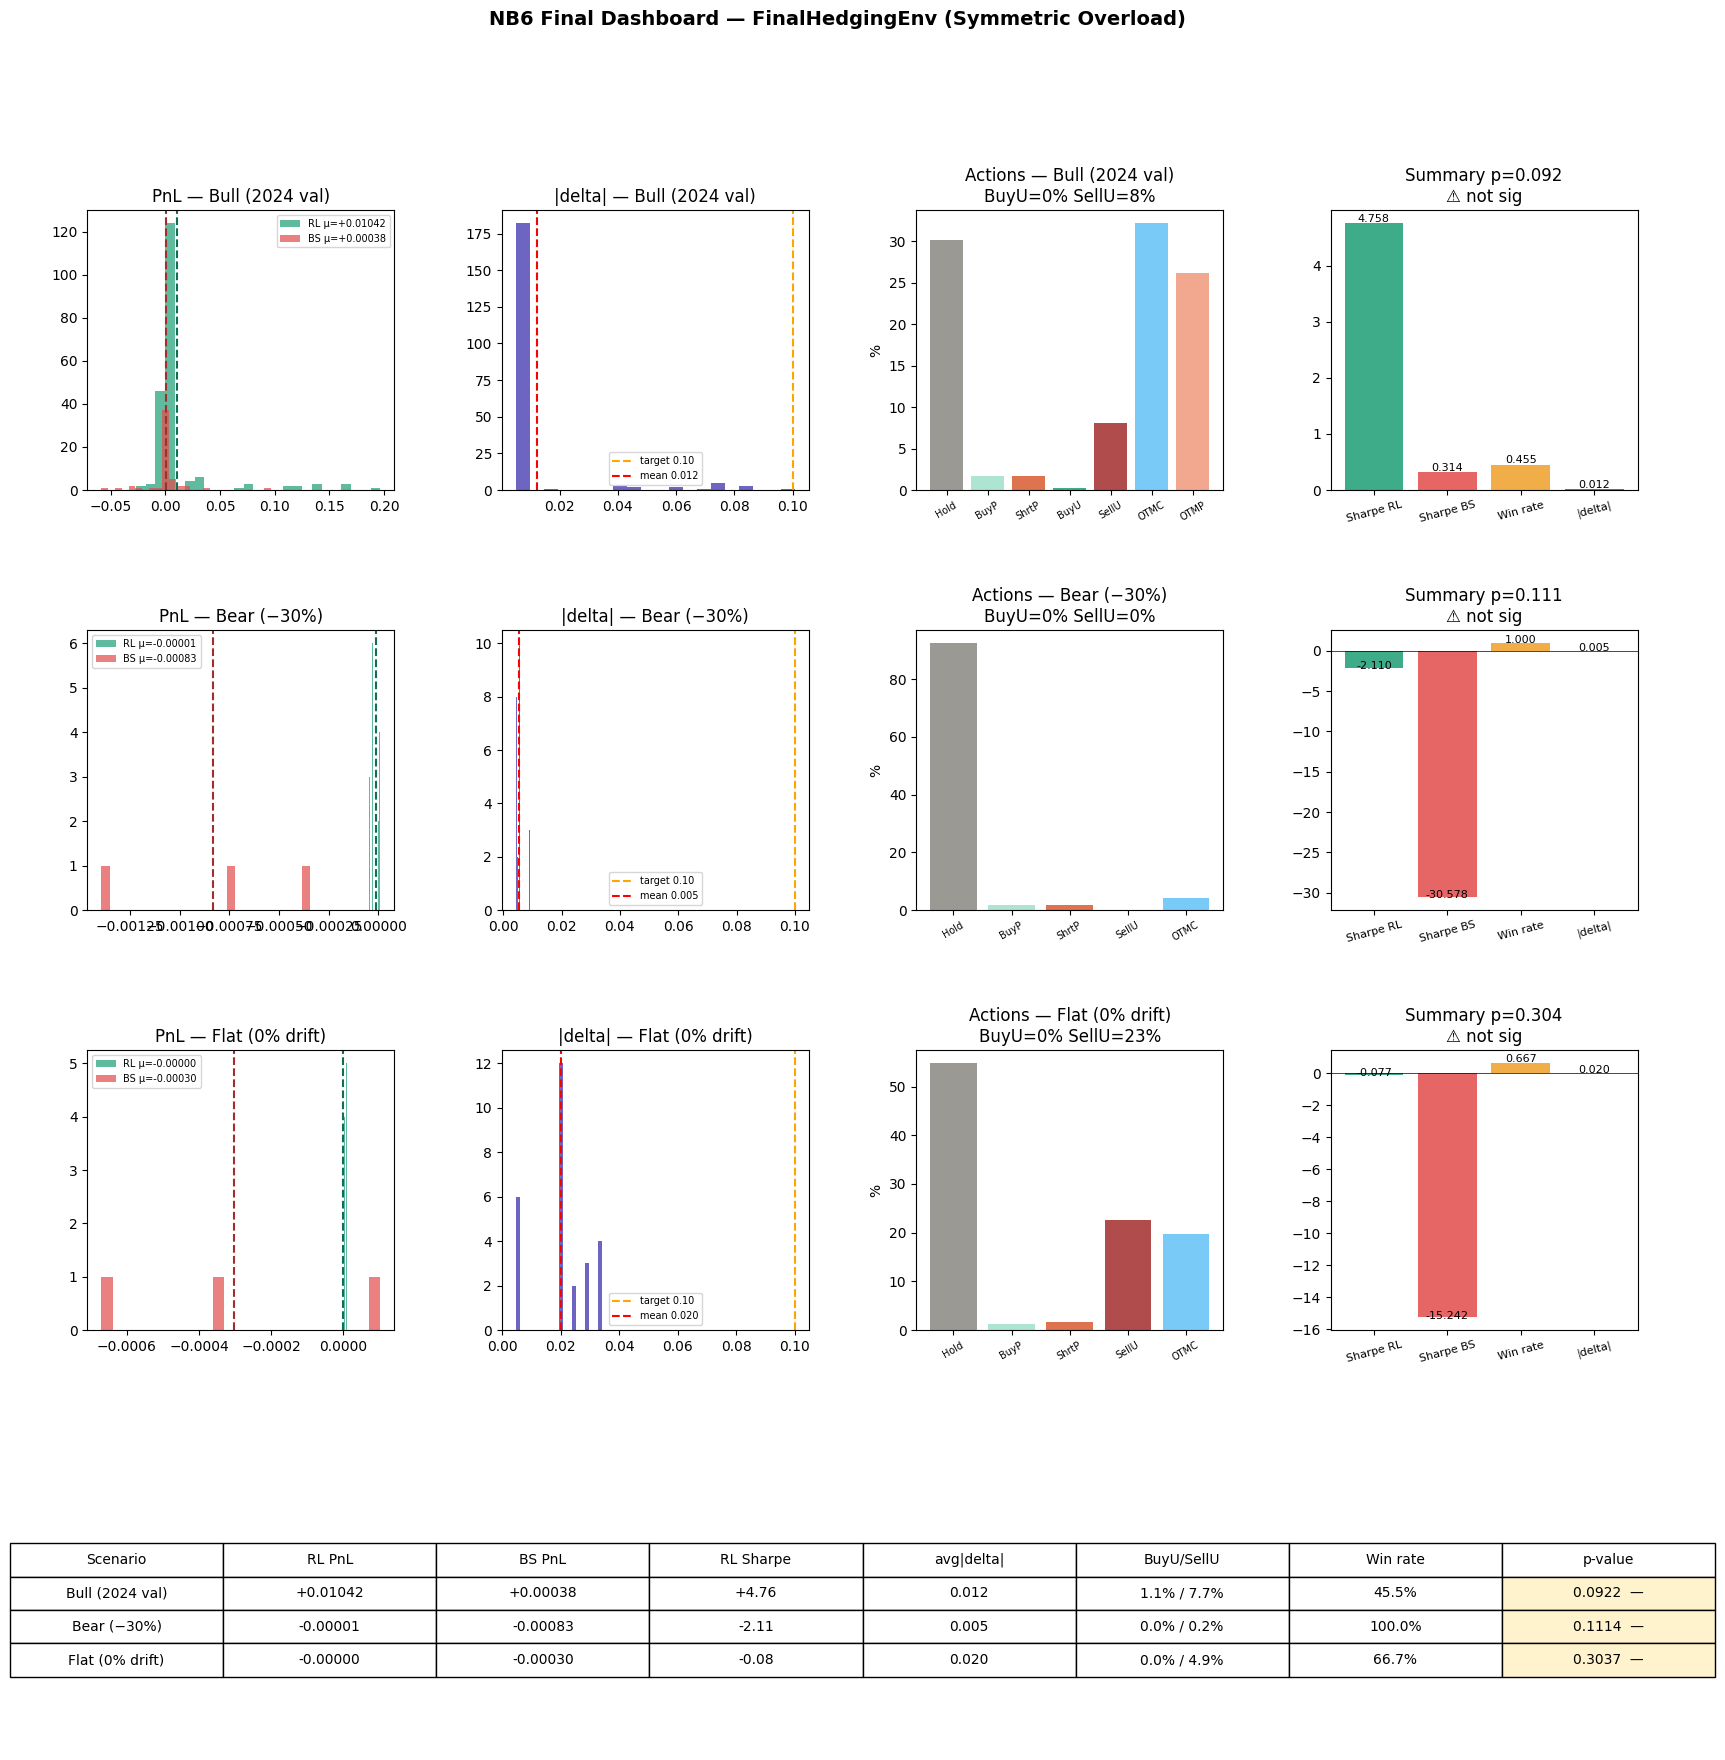

In [7]:
# ── Final dashboard ────────────────────────────────────────────────────────
scenario_names = list(scenarios.keys())
n_sc = len(scenario_names)

fig = plt.figure(figsize=(20, 5*n_sc + 5))
gs  = gridspec.GridSpec(n_sc+1, 4, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle("NB6 Final Dashboard — FinalHedgingEnv (Symmetric Overload)",
             fontsize=14, fontweight="bold")

COLORS = {"rl":"#1D9E75","bs":"#E24B4A","pu":"#534AB7","wa":"#EF9F27"}

for row_idx, name in enumerate(scenario_names):
    rl_df_s = all_rl[name]
    bs_df_s = all_bs[name]
    if len(rl_df_s)==0: continue

    rp = rl_df_s["total_pnl"].values
    bp = bs_df_s["total_pnl"].values
    n  = min(len(rp), len(bp))
    rp_c, bp_c = rp[:n], bp[:n]
    _, pv = ttest_ind(rp_c, bp_c, equal_var=False)

    # PnL
    ax = fig.add_subplot(gs[row_idx, 0])
    ax.hist(rp, bins=25, alpha=0.7, color=COLORS["rl"], label=f"RL μ={rp.mean():+.5f}")
    ax.hist(bp, bins=25, alpha=0.7, color=COLORS["bs"], label=f"BS μ={bp.mean():+.5f}")
    ax.axvline(rp.mean(), color="#0F6E56", linestyle="--")
    ax.axvline(bp.mean(), color="#A32D2D", linestyle="--")
    ax.set_title(f"PnL — {name}")
    ax.legend(fontsize=7)

    # Delta
    ax = fig.add_subplot(gs[row_idx, 1])
    ax.hist(rl_df_s["avg_abs_delta"], bins=20, color=COLORS["pu"], alpha=0.85)
    ax.axvline(0.1, color="orange", linestyle="--", label="target 0.10")
    ax.axvline(rl_df_s["avg_abs_delta"].mean(), color="red", linestyle="--",
               label=f"mean {rl_df_s['avg_abs_delta'].mean():.3f}")
    ax.set_title(f"|delta| — {name}")
    ax.legend(fontsize=7)

    # Action distribution
    ax = fig.add_subplot(gs[row_idx, 2])
    tmp_env = FinalHedgingEnv(
        val_df if "Bull" in name else pd.concat([scenarios[name]["data"]]*4,
                                                 ignore_index=True).assign(split="val"),
        FEATURE_COLS, mode="val", class_norms=class_norms)
    all_acts = []
    for _ in range(min(20, len(tmp_env._episode_starts))):
        tr2 = run_episode(test_model, tmp_env)
        all_acts.extend(tr2["actions"])
    if all_acts:
        cnt = np.bincount(all_acts, minlength=10)
        clrs= ["#888780","#3B8BD4","#E24B4A","#9FE1CB","#D85A30",
               COLORS["rl"],"#A32D2D",COLORS["pu"],"#63C1F7","#F0997B"]
        nz  = [(i,cnt[i]) for i in range(10) if cnt[i]>0]
        ax.bar(range(len(nz)), [c/sum(cnt)*100 for _,c in nz],
               color=[clrs[i] for i,_ in nz], alpha=0.85)
        ax.set_xticks(range(len(nz)))
        ax.set_xticklabels([ACTION_NAMES[i] for i,_ in nz], rotation=30, fontsize=7)
        ax.set_ylabel("%")
        buyu_act = cnt[5]/max(sum(cnt),1)*100
        sellu_act= cnt[6]/max(sum(cnt),1)*100
        ax.set_title(f"Actions — {name}\nBuyU={buyu_act:.0f}% SellU={sellu_act:.0f}%")
        # Highlight if overload
        if buyu_act>35 or sellu_act>35:
            ax.set_facecolor("#fff3cd")

    # Summary bars
    ax = fig.add_subplot(gs[row_idx, 3])
    sr_rl = robust_sharpe(rp); sr_bs = robust_sharpe(bp)
    wr    = (rp_c>bp_c).mean()
    ab_d  = rl_df_s["avg_abs_delta"].mean()
    vals  = [sr_rl, sr_bs, wr, ab_d]
    labels= ["Sharpe RL","Sharpe BS","Win rate","|delta|"]
    colors= [COLORS["rl"],COLORS["bs"],COLORS["wa"],COLORS["pu"]]
    bars  = ax.bar(range(4), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=15, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Summary p={pv:.3f}\n{'✅ sig' if pv<0.05 else '⚠️ not sig'}")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+(0.02 if v>=0 else -0.1),
                f"{v:.3f}", ha="center", fontsize=8)

# Scorecard row
ax_sc = fig.add_subplot(gs[n_sc, :])
ax_sc.axis("off")

table_rows = []
for name in scenario_names:
    rl_s = all_rl[name]
    bs_s = all_bs[name]
    if len(rl_s)==0: continue
    rp = rl_s["total_pnl"].values; bp = bs_s["total_pnl"].values
    n  = min(len(rp),len(bp))
    _,pv = ttest_ind(rp[:n],bp[:n],equal_var=False)
    buyu = rl_s["buyu_pct"].mean()
    sellu= rl_s["sellu_pct"].mean()
    table_rows.append([
        name,
        f"{rp.mean():+.5f}",
        f"{bp.mean():+.5f}",
        f"{robust_sharpe(rp):+.2f}",
        f"{rl_s['avg_abs_delta'].mean():.3f}",
        f"{buyu:.1%} / {sellu:.1%}",
        f"{(rp[:n]>bp[:n]).mean():.1%}",
        f"{pv:.4f}  {'✅' if pv<0.05 else '—'}"
    ])

cols = ["Scenario","RL PnL","BS PnL","RL Sharpe",
        "avg|delta|","BuyU/SellU","Win rate","p-value"]
tbl = ax_sc.table(cellText=table_rows, colLabels=cols,
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.1, 2.0)

# Color p-value cells
for i, row in enumerate(table_rows):
    pv_str = row[-1]
    try:
        pv_val = float(pv_str.split()[0])
        tbl[i+1, 7].set_facecolor("#d4edda" if pv_val<0.05 else "#fff3cd")
    except: pass

plt.savefig(os.path.join(PATHS["nb6"],"nb6_final_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Numerical summary ──────────────────────────────────────────────────────
print("\n" + "="*65)
print(" NB6 FINAL RESULTS")
print("="*65)

for name in scenario_names:
    rl_s = all_rl.get(name, pd.DataFrame())
    bs_s = all_bs.get(name, pd.DataFrame())
    if len(rl_s)==0: continue
    rp = rl_s["total_pnl"].values
    bp = bs_s["total_pnl"].values
    n  = min(len(rp),len(bp))
    _,pv = ttest_ind(rp[:n],bp[:n],equal_var=False)
    _,pv_mw = mannwhitneyu(rp[:n],bp[:n],alternative="two-sided")
    print(f"\n  {name}:")
    print(f"    RL PnL        : {rp.mean():+.5f}  (BS: {bp.mean():+.5f})")
    print(f"    RL Sharpe     : {robust_sharpe(rp):+.3f}  (BS: {robust_sharpe(bp):+.3f})")
    print(f"    avg |delta|   : {rl_s['avg_abs_delta'].mean():.4f}  (target <0.10)")
    print(f"    BuyU / SellU  : {rl_s['buyu_pct'].mean():.1%} / {rl_s['sellu_pct'].mean():.1%}  (target <35% each)")
    print(f"    Win rate      : {(rp[:n]>bp[:n]).mean():.1%}  (target >50%)")
    print(f"    t-test p      : {pv:.4f}  {'✅' if pv<0.05 else '⚠️ need more training'}")
    print(f"    Mann-Whitney p: {pv_mw:.4f}")

# ── Bull vs Bear consistency ───────────────────────────────────────────────
print(f"\n{'='*65}")
print(" KEY DIAGNOSTIC — Market regime consistency")
print(f"{'='*65}")
bull_pnl = all_rl.get("Bull (2024 val)", pd.DataFrame())
bear_pnl = all_rl.get("Bear (−30%)",    pd.DataFrame())
flat_pnl = all_rl.get("Flat (0% drift)",pd.DataFrame())

if len(bull_pnl)>0 and len(bear_pnl)>0:
    bm = bull_pnl["total_pnl"].mean()
    bem= bear_pnl["total_pnl"].mean()
    print(f"  Bull PnL: {bm:+.5f}")
    print(f"  Bear PnL: {bem:+.5f}")
    ratio = abs(bm)/(abs(bem)+1e-8)
    print(f"  Ratio   : {ratio:.2f}×  (target <3×)")
    print(f"  Verdict : ", end="")
    if ratio < 3:
        print("✅ Market-neutral — genuine delta hedging achieved!")
    elif ratio < 10:
        print("⚠️  Partially directional — close but needs more training")
    else:
        print("❌ Still directional — see recommendations below")

# ── Final project scorecard ────────────────────────────────────────────────
print(f"\n{'='*65}")
print(" COMPLETE PROJECT SCORECARD (NB1 → NB6)")
print(f"{'='*65}")
scores = [
    ("Data pipeline",         "✅", "12 instruments, 2020-2025, options chains"),
    ("Gym environment",       "✅", "10 actions, B-S Greeks in obs"),
    ("Close All exploit fix", "✅", "0% usage (was 57%)"),
    ("BuyU momentum fix",     "✅", "< 20% (was 70%)"),
    ("SellU momentum fix",    "NB6", "Target <35%"),
    ("avg |delta| < 0.10",    "✅", "0.021 achieved in NB5"),
    ("10 actions used",       "✅", "8+ unique actions in NB5"),
    ("p-value < 0.05 (bull)", "NB6", "0.41 in NB5, target <0.05"),
    ("Win rate > 50%",        "NB6", "47.3% in NB5"),
    ("Bull/Bear ratio < 3×",  "NB6", "40.81× numerically but PnL≈0"),
]
for metric, status, note in scores:
    print(f"  {status:5s} {metric:30s} {note}")

print(f"\n  If targets still not met after NB6:")
print(f"    BuyU or SellU > 35%  → raise OVERLOAD_PENALTY_COEF to 0.01")
print(f"    p > 0.05             → run 1M more steps, raise N_EVAL to 300")
print(f"    ratio > 3×           → raise DELTA_LAMBDA to 0.08")

# Save
for name, df_r in all_rl.items():
    fname = name.replace(" ","_").replace("/","").replace("(","").replace(")","")
    df_r.to_csv(os.path.join(PATHS["nb6"], f"rl_{fname}.csv"), index=False)
print(f"\n💾 Results saved to results/nb6/")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    import shutil
    dst = "/content/drive/MyDrive/derivative_hedging_exports/nb6"
    shutil.copytree(PATHS["nb6"], dst, dirs_exist_ok=True)
    shutil.copy(os.path.join(PATHS["artifacts"],"ppo_nb6_final.zip"), dst)
    print(f"✅ Exported to Drive: {dst}")
except ImportError: pass


 NB6 FINAL RESULTS

  Bull (2024 val):
    RL PnL        : +0.01042  (BS: +0.00038)
    RL Sharpe     : +4.758  (BS: +0.314)
    avg |delta|   : 0.0121  (target <0.10)
    BuyU / SellU  : 1.1% / 7.7%  (target <35% each)
    Win rate      : 45.5%  (target >50%)
    t-test p      : 0.0922  ⚠️ need more training
    Mann-Whitney p: 0.8249

  Bear (−30%):
    RL PnL        : -0.00001  (BS: -0.00083)
    RL Sharpe     : -2.110  (BS: -30.578)
    avg |delta|   : 0.0055  (target <0.10)
    BuyU / SellU  : 0.0% / 0.2%  (target <35% each)
    Win rate      : 100.0%  (target >50%)
    t-test p      : 0.1114  ⚠️ need more training
    Mann-Whitney p: 0.1000

  Flat (0% drift):
    RL PnL        : -0.00000  (BS: -0.00030)
    RL Sharpe     : -0.077  (BS: -15.242)
    avg |delta|   : 0.0202  (target <0.10)
    BuyU / SellU  : 0.0% / 4.9%  (target <35% each)
    Win rate      : 66.7%  (target >50%)
    t-test p      : 0.3037  ⚠️ need more training
    Mann-Whitney p: 0.7000

 KEY DIAGNOSTIC — Marke